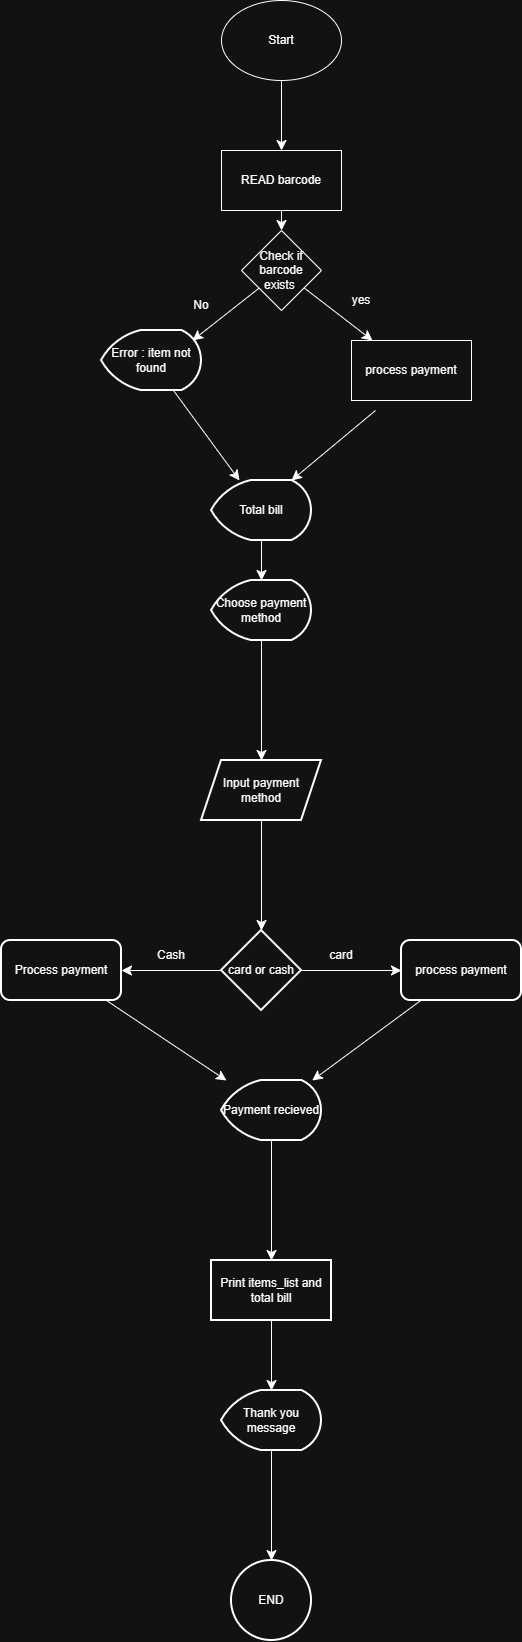

START CHECKOUT_PROCESS
    SET total_bill = 0
    SET items_list = []  
    WHILE customer has items to scan
        READ barcode
        IF barcode EXISTS in database THEN
            GET item_name AND item_price
            total_bill = total_bill + item_price
            ADD item_name TO items_list 
        ELSE
            DISPLAY "Error: item not found on the list"
        ENDIF
    ENDWHILE 

 DISPLAY "Total: ", total_bill

DISPLAY "Choose payment method: cash/card"
    INPUT payment_method

IF payment_method == "card" THEN
        READ card_information 
        CALL process_payment(total_bill) 
        DISPLAY "Payment received"
    ELSE
        INPUT cash_received
        SET change = cash_received - total_bill
        DISPLAY "Cash received. Change: ", change
    ENDIF

FOR EACH item IN items_list DO
        DECREMENT inventory_stock(item) BY 1
    ENDFOR

 PRINT RECEIPT(items_list, total_bill)
    DISPLAY "Dear customer, thank you for shopping with us!"
END CHECKOUT_PROCESS
